In [1]:
import numpy as np
import matplotlib.pyplot as plt

$\chi ^2( \theta_k) = (y_i - f(x_i, \theta_k ))C_{ij}^{-1}(y_j - f(x_j, \theta_k))$

In [2]:
# Definimos funciones f, chi^2 y una propuesta diagonal de C

# Para este caso f sera la ecuacion de la recta, pero puede cambiarse a cualquier otra funcion a la que se desee ajustar los datos
def f_lin(x, theta):
    return theta[0]*x + theta[1] #theta[0] sera la pendiente y theta[1] la coordenada de origen

def f_exp(x,theta):
    return theta[0]*np.exp(theta[1]*x)

# Definimos una propuesta de C, donde todos los errores son iguales (1) y no estan correlacionados, es decir la matriz C es lineal
def defC(y):
    return np.eye(len(y))

# Ahora definimos a la funcion chi^2, para practicidad, haremos primero una funcion que calcule la inversa de C
def Cinv(C):
    return np.linalg.inv(C)

# Para optimizar el calculo de la minimizacion se calculara chi^2 no solo para los parametros de preba, al mismo tiempo se calculara para los parametros posibles al rededor
# Hacer esto requiere que tengamos el vector de datos en la dimensionalidad adecuada y de f en evaluada en los parametros de alrededor y el central
    
def LogL(y, f, Cinv):
    vec = y-f
    c2 = vec @ Cinv @ vec
    return -c2 #Se calcula de forma matricial pues asi es mucho mas rapido que usando ciclos for

In [139]:
theta = np.array([-2, 2])

sigma = np.array([0.001, 0.001])

x = np.linspace(0,10, 50)

# generamos datos para hacer el ajuste lineal
y = np.random.normal(3*x-1, 0.3)

C_inv = Cinv(defC(y))

n_iter = 10000000

In [140]:
chain = []
chain.append(theta)

f = f_lin(x, theta)
logL = LogL(y, f, C_inv)

for _ in range(n_iter):
    # generamos los parametros propuesta
    theta_prop = np.random.normal(chain[len(chain)-1],sigma)
    # calculamos logL de los parametros propuestos
    f_prop = f_lin(x, theta_prop)
    logL_prop = LogL(y, f_prop, C_inv)

    if logL_prop>logL:
        chain.append(theta_prop)
        logL = logL_prop
    else:
        p_acc = np.random.uniform()
        crit = (logL_prop - logL)
        crit2 = np.log(p_acc)
        if crit>crit2:
            chain.append(theta_prop)
            logL = logL_prop

In [141]:
chain[len(chain)-1]

array([ 3.02993248, -1.17400503])

In [142]:
chain = np.array(chain).T

In [ ]:
limit = len(chain.T)-50000

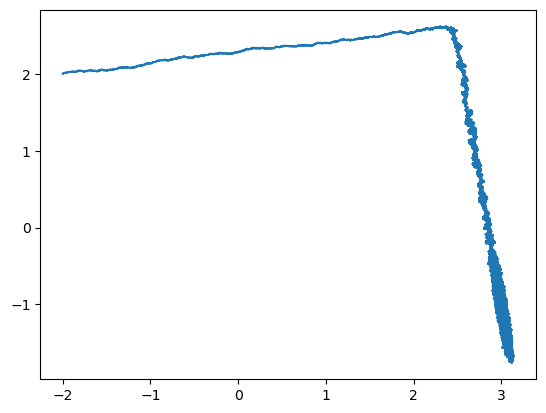

In [143]:
plt.plot(chain[0][limit:], chain[1][limit:])

(array([  52.,   48.,  100.,  275.,  516.,  760.,  978., 1004., 1622.,
        1448., 1307., 1339., 1579., 2374., 3679., 4359., 4488., 4080.,
        3813., 3630., 3375., 2605., 1809., 1395., 1157.,  850.,  607.,
         453.,  223.,   75.]),
 array([2.92538164, 2.93039063, 2.93539963, 2.94040862, 2.94541762,
        2.95042662, 2.95543561, 2.96044461, 2.9654536 , 2.9704626 ,
        2.9754716 , 2.98048059, 2.98548959, 2.99049858, 2.99550758,
        3.00051658, 3.00552557, 3.01053457, 3.01554356, 3.02055256,
        3.02556156, 3.03057055, 3.03557955, 3.04058855, 3.04559754,
        3.05060654, 3.05561553, 3.06062453, 3.06563353, 3.07064252,
        3.07565152]),
 <BarContainer object of 30 artists>)

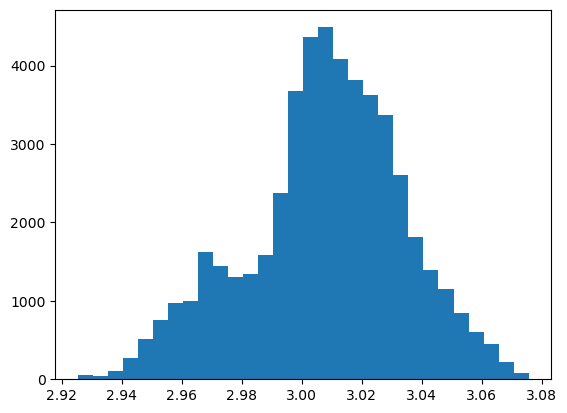

In [146]:
plt.hist(chain[0][limit:],bins=30)

(array([ 330., 1283., 1423., 1296., 1338.,  573., 2732., 4862., 4849.,
        3714., 6031., 2825., 2280.,  833.,  579.,  226.,  902., 2284.,
        1421.,  710.,  484.,  580.,  144.,  770., 1575., 1696., 1830.,
        1466.,  624.,  340.]),
 array([-1.29887717, -1.28302335, -1.26716954, -1.25131572, -1.23546191,
        -1.21960809, -1.20375428, -1.18790046, -1.17204665, -1.15619283,
        -1.14033902, -1.1244852 , -1.10863139, -1.09277757, -1.07692376,
        -1.06106994, -1.04521613, -1.02936231, -1.0135085 , -0.99765468,
        -0.98180087, -0.96594705, -0.95009324, -0.93423942, -0.91838561,
        -0.90253179, -0.88667798, -0.87082416, -0.85497035, -0.83911653,
        -0.82326272]),
 <BarContainer object of 30 artists>)

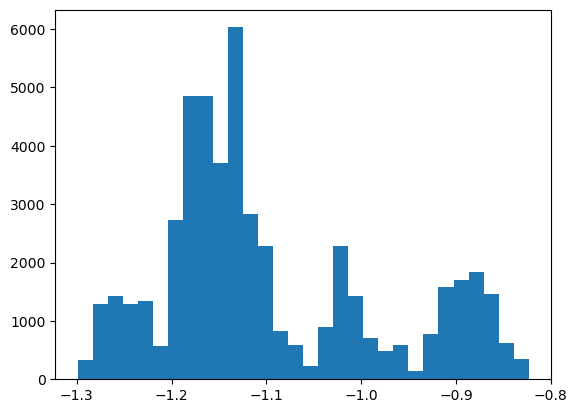

In [147]:
plt.hist(chain[1][limit:],bins=30)

In [150]:
theta = np.array([1,0])

sigma = np.array([0.001, 0.001])

x = np.linspace(0, 2, 50)

# generamos datos para hacer el ajuste lineal
y = np.random.normal(3*np.exp(2*x), 0.3)

C_inv = Cinv(defC(y))

n_iter = 1000000

In [151]:
chain = []
chain.append(theta)

f = f_exp(x, theta)
logL = LogL(y, f, C_inv)

for _ in range(n_iter):
    # generamos los parametros propuesta
    theta_prop = np.random.normal(chain[len(chain)-1],sigma)
    # calculamos logL de los parametros propuestos
    f_prop = f_exp(x, theta_prop)
    logL_prop = LogL(y, f_prop, C_inv)

    if logL_prop>logL:
        chain.append(theta_prop)
        logL = logL_prop
    else:
        p_acc = np.random.uniform()
        crit = (logL_prop - logL)
        crit2 = np.log(p_acc)
        if crit>crit2:
            chain.append(theta_prop)
            logL = logL_prop

In [152]:
chain = np.array(chain).T

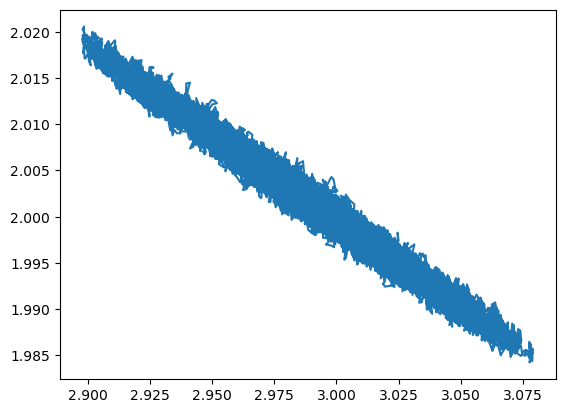

In [157]:
plt.plot(chain[0][limit:], chain[1][limit:])

In [154]:
limit = len(chain.T)-50000

(array([ 101.,  279.,  291.,  554.,  789.,  817.,  782.,  775., 1476.,
        2132., 2398., 2564., 2812., 3352., 3380., 3624., 4267., 4017.,
        3645., 2771., 2353., 2007., 1052., 1020.,  973.,  940.,  411.,
         244.,  132.,   42.]),
 array([2.89767498, 2.90372376, 2.90977254, 2.91582132, 2.9218701 ,
        2.92791888, 2.93396766, 2.94001644, 2.94606522, 2.952114  ,
        2.95816279, 2.96421157, 2.97026035, 2.97630913, 2.98235791,
        2.98840669, 2.99445547, 3.00050425, 3.00655303, 3.01260181,
        3.01865059, 3.02469937, 3.03074815, 3.03679693, 3.04284571,
        3.04889449, 3.05494327, 3.06099205, 3.06704083, 3.07308961,
        3.07913839]),
 <BarContainer object of 30 artists>)

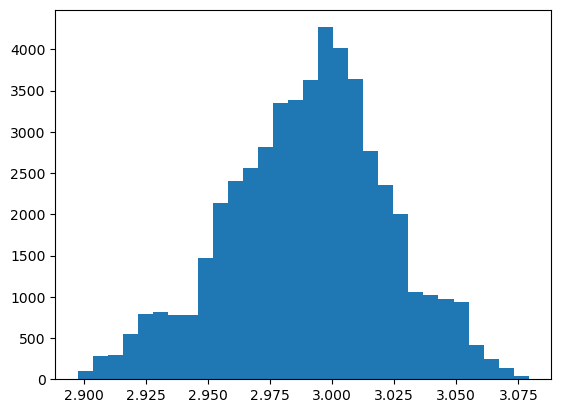

In [155]:
plt.hist(chain[0][limit:],bins=30)

(array([  28.,  102.,  209.,  438.,  761., 1037., 1127., 1367., 2034.,
        2685., 3313., 3853., 4496., 4171., 3727., 3505., 3301., 2850.,
        2621., 2191., 1566.,  964.,  893.,  922.,  755.,  479.,  319.,
         202.,   71.,   13.]),
 array([1.98421775, 1.98543014, 1.98664254, 1.98785493, 1.98906733,
        1.99027972, 1.99149212, 1.99270452, 1.99391691, 1.99512931,
        1.9963417 , 1.9975541 , 1.99876649, 1.99997889, 2.00119128,
        2.00240368, 2.00361607, 2.00482847, 2.00604086, 2.00725326,
        2.00846565, 2.00967805, 2.01089044, 2.01210284, 2.01331523,
        2.01452763, 2.01574002, 2.01695242, 2.01816481, 2.01937721,
        2.0205896 ]),
 <BarContainer object of 30 artists>)

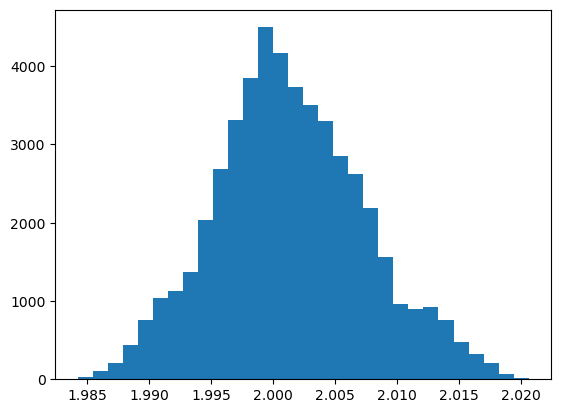

In [156]:
plt.hist(chain[1][limit:],bins=30)

In [112]:
data = np.genfromtxt("line-1.dat", delimiter=" ", usemask=False)

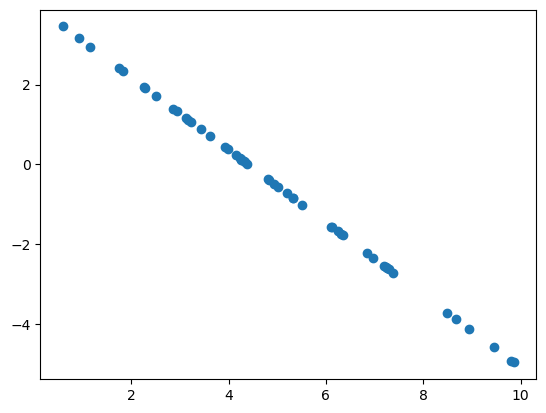

In [113]:
plt.scatter(data[0],data[1])

In [114]:
x = data[0]
y = data[1]

upper = [10,10]
lower = [-10,-10]

theta = np.array([0,0])
sigma = np.array([0.01, 0.01])

chain = []
chain.append(theta)

C_lin = np.diag(data[2])

C_inv = Cinv(C_lin)

n_iter = 1000000

f = f_lin(x, theta)
logL = LogL(y, f, C_inv)

for _ in range(n_iter):
    # generamos los parametros propuesta
    theta_prop = np.random.normal(chain[len(chain)-1],sigma)
    param_acc = True

    for i in range(len(theta)):
        param_acc = param_acc and bool(theta[i]<upper[i]) and bool(theta[i]>lower[i])
    if param_acc:
        # calculamos logL de los parametros propuestos
        f_prop = f_lin(x, theta_prop)
        logL_prop = LogL(y, f_prop, C_inv)
    
        if logL_prop>logL:
            chain.append(theta_prop)
            logL = logL_prop
        else:
            p_acc = np.random.uniform()
            crit = (logL_prop - logL)
            crit2 = np.log(p_acc)
            if crit>crit2:
                chain.append(theta_prop)
                logL = logL_prop

In [115]:
chain = np.array(chain).T

In [117]:
limit = len(chain.T)-10000
m_notail = np.array(chain[0][limit:])
b_notail = np.array(chain[1][limit:])
m_median = np.median(m_notail)
b_median = np.median(b_notail)
print(m_median, b_median)

-0.9097152591864934 3.9949535926776587


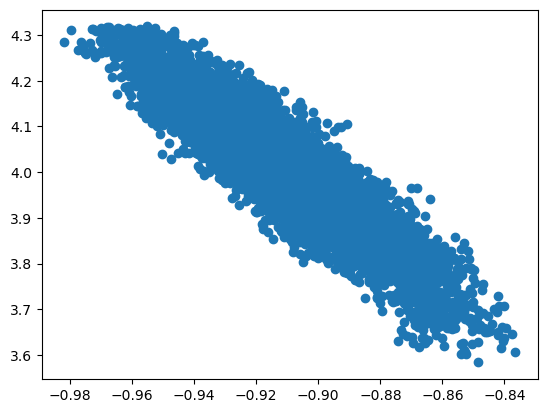

In [118]:
plt.scatter(chain[0][limit:], chain[1][limit:])

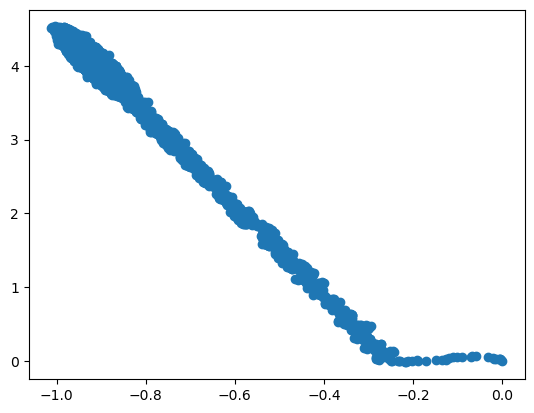

In [119]:
plt.scatter(chain[0], chain[1])

(array([  3.,   9.,  22.,  43.,  66., 129., 179., 225., 371., 461., 571.,
        626., 695., 819., 849., 898., 868., 767., 619., 489., 409., 261.,
        200., 152., 108.,  73.,  43.,  25.,  12.,   8.]),
 array([-0.98184055, -0.97699586, -0.97215117, -0.96730649, -0.9624618 ,
        -0.95761711, -0.95277242, -0.94792773, -0.94308304, -0.93823835,
        -0.93339366, -0.92854897, -0.92370429, -0.9188596 , -0.91401491,
        -0.90917022, -0.90432553, -0.89948084, -0.89463615, -0.88979146,
        -0.88494677, -0.88010209, -0.8752574 , -0.87041271, -0.86556802,
        -0.86072333, -0.85587864, -0.85103395, -0.84618926, -0.84134457,
        -0.83649989]),
 <BarContainer object of 30 artists>)

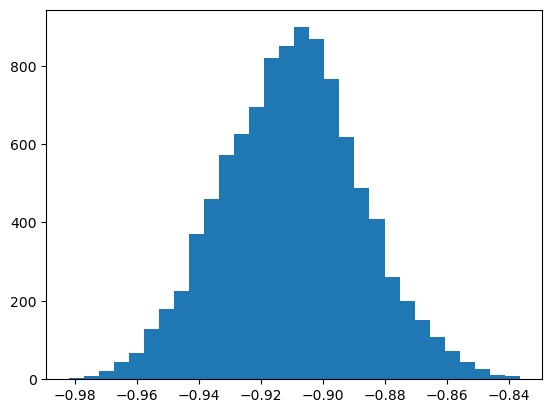

In [120]:
plt.hist(chain[0][limit:],bins=30)

(array([  5.,  13.,  21.,  41.,  52.,  63.,  50., 125., 131., 212., 347.,
        443., 478., 621., 866., 905., 771., 741., 727., 558., 550., 673.,
        459., 356., 252., 222., 101.,  91.,  81.,  45.]),
 array([3.58351273, 3.60802414, 3.63253556, 3.65704698, 3.68155839,
        3.70606981, 3.73058123, 3.75509264, 3.77960406, 3.80411548,
        3.82862689, 3.85313831, 3.87764973, 3.90216114, 3.92667256,
        3.95118398, 3.97569539, 4.00020681, 4.02471823, 4.04922964,
        4.07374106, 4.09825248, 4.12276389, 4.14727531, 4.17178673,
        4.19629814, 4.22080956, 4.24532098, 4.26983239, 4.29434381,
        4.31885523]),
 <BarContainer object of 30 artists>)

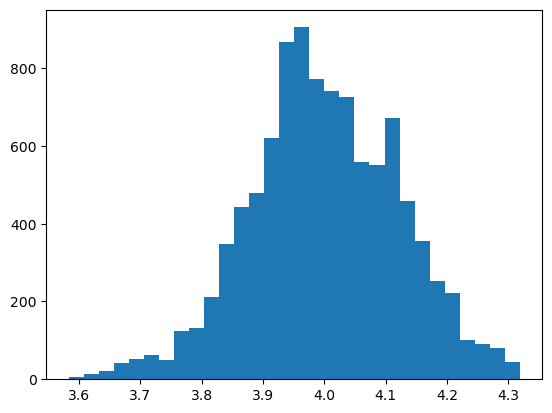

In [121]:
plt.hist(chain[1][limit:],bins=30)

In [122]:
data = np.genfromtxt("line-2.dat", delimiter=" ", usemask=False)

In [123]:
x = data[0]
y = data[1]

upper = [10,10]
lower = [-10,-10]

theta = np.array([0,0])
sigma = np.array([0.01, 0.01])

chain = []
chain.append(theta)

C_lin = np.diag(data[2])

C_inv = Cinv(C_lin)

n_iter = 1000000

f = f_lin(x, theta)
logL = LogL(y, f, C_inv)

for _ in range(n_iter):
    # generamos los parametros propuesta
    theta_prop = np.random.normal(chain[len(chain)-1],sigma)
    param_acc = True

    for i in range(len(theta)):
        param_acc = param_acc and bool(theta[i]<upper[i]) and bool(theta[i]>lower[i])
    if param_acc:
        # calculamos logL de los parametros propuestos
        f_prop = f_lin(x, theta_prop)
        logL_prop = LogL(y, f_prop, C_inv)
    
        if logL_prop>logL:
            chain.append(theta_prop)
            logL = logL_prop
        else:
            p_acc = np.random.uniform()
            crit = (logL_prop - logL)
            crit2 = np.log(p_acc)
            if crit>crit2:
                chain.append(theta_prop)
                logL = logL_prop

In [124]:
chain = np.array(chain).T

In [125]:
limit = len(chain.T)-10000
m_notail = np.array(chain[0][limit:])
b_notail = np.array(chain[1][limit:])
m_median = np.median(m_notail)
b_median = np.median(b_notail)
print(m_median, b_median)

-0.9686414915665998 4.564918012348199


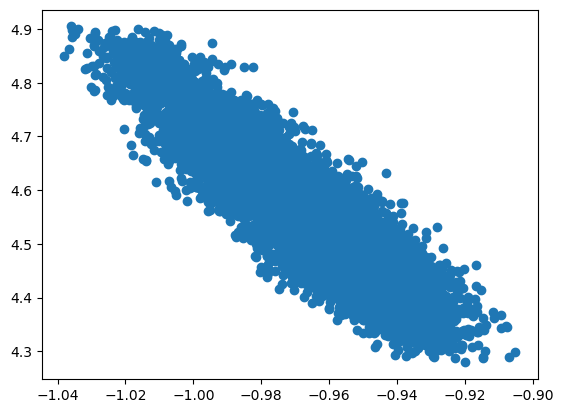

In [126]:
plt.scatter(chain[0][limit:], chain[1][limit:])

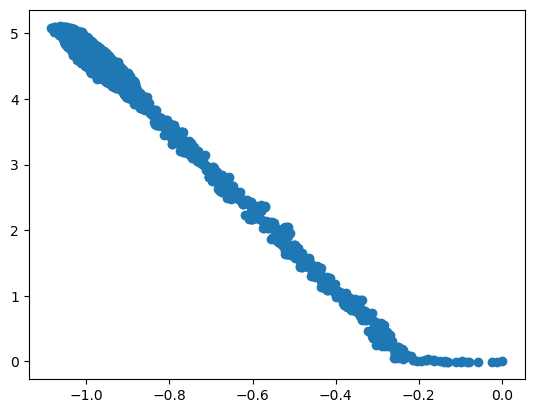

In [127]:
plt.scatter(chain[0], chain[1])

(array([  7.,  10.,  19.,  50.,  78., 110., 131., 183., 280., 364., 514.,
        641., 671., 793., 692., 721., 711., 710., 755., 677., 575., 485.,
        338., 189., 149.,  79.,  35.,  24.,   3.,   6.]),
 array([-1.03799067, -1.03356417, -1.02913766, -1.02471116, -1.02028465,
        -1.01585815, -1.01143164, -1.00700514, -1.00257863, -0.99815213,
        -0.99372563, -0.98929912, -0.98487262, -0.98044611, -0.97601961,
        -0.9715931 , -0.9671666 , -0.96274009, -0.95831359, -0.95388708,
        -0.94946058, -0.94503408, -0.94060757, -0.93618107, -0.93175456,
        -0.92732806, -0.92290155, -0.91847505, -0.91404854, -0.90962204,
        -0.90519553]),
 <BarContainer object of 30 artists>)

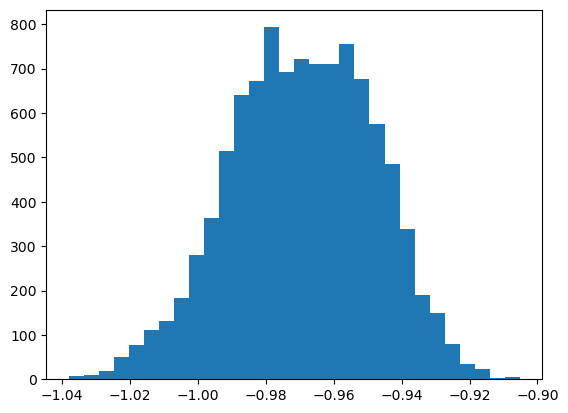

In [128]:
plt.hist(chain[0][limit:],bins=30)

(array([ 12.,  48.,  83., 102., 212., 251., 364., 532., 616., 596., 681.,
        576., 513., 583., 629., 629., 613., 675., 609., 415., 259., 236.,
        185., 182.,  99.,  76.,  91.,  71.,  42.,  20.]),
 array([4.27902218, 4.29988151, 4.32074084, 4.34160016, 4.36245949,
        4.38331881, 4.40417814, 4.42503747, 4.44589679, 4.46675612,
        4.48761544, 4.50847477, 4.5293341 , 4.55019342, 4.57105275,
        4.59191207, 4.6127714 , 4.63363073, 4.65449005, 4.67534938,
        4.6962087 , 4.71706803, 4.73792736, 4.75878668, 4.77964601,
        4.80050533, 4.82136466, 4.84222399, 4.86308331, 4.88394264,
        4.90480197]),
 <BarContainer object of 30 artists>)

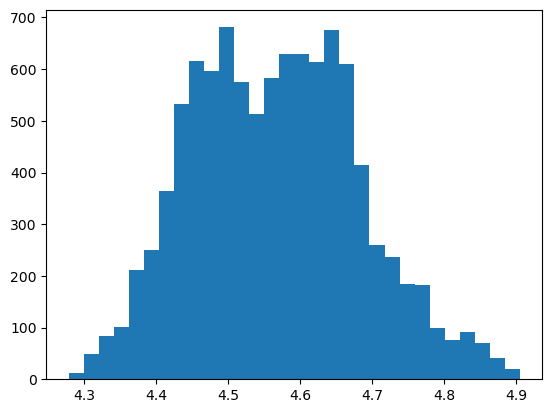

In [129]:
plt.hist(chain[1][limit:],bins=30)